# Google Play Store Apps Analysis

**Instructions**
1. Run the first cell.
2. Click **Choose Files** and upload `googleplaystore.csv`.
3. Run the remaining cells in order.


In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

try:
    import seaborn as sns
except ImportError:
    sns=None

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded:", filename)

df = pd.read_csv(filename)
df.head()


Saving googleplaystore.csv to googleplaystore.csv
Uploaded: googleplaystore.csv


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [2]:
# Dataset Information
print("Shape:",df.shape)
print("\nColumns")
print(df.columns)
print("\nData Types")
print(df.dtypes)
print("\nInfo")
df.info()
print("\nMissing Values")
print(df.isnull().sum())


Shape: (10841, 13)

Columns
Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Data Types
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 n

In [3]:
# Data Cleaning
df=df.drop_duplicates()

df['Reviews']=pd.to_numeric(df['Reviews'],errors='coerce')
df['Rating']=pd.to_numeric(df['Rating'],errors='coerce')
df['Installs']=pd.to_numeric(df['Installs'].astype(str).str.replace('+','',regex=False).str.replace(',','',regex=False),errors='coerce')
df['Price']=pd.to_numeric(df['Price'].astype(str).str.replace('$','',regex=False),errors='coerce')

df=df.dropna(subset=['Rating','Reviews','Installs'])

print(df.describe(include='all'))


           App Category       Rating       Reviews                Size  \
count     8892     8892  8892.000000  8.892000e+03                8892   
unique    8196       33          NaN           NaN                 414   
top     ROBLOX   FAMILY          NaN           NaN  Varies with device   
freq         9     1718          NaN           NaN                1468   
mean       NaN      NaN     4.187877  4.727764e+05                 NaN   
std        NaN      NaN     0.522377  2.905052e+06                 NaN   
min        NaN      NaN     1.000000  1.000000e+00                 NaN   
25%        NaN      NaN     4.000000  1.640000e+02                 NaN   
50%        NaN      NaN     4.300000  4.714500e+03                 NaN   
75%        NaN      NaN     4.500000  7.126675e+04                 NaN   
max        NaN      NaN     5.000000  7.815831e+07                 NaN   

            Installs  Type        Price Content Rating Genres    Last Updated  \
count   8.892000e+03  8892  88

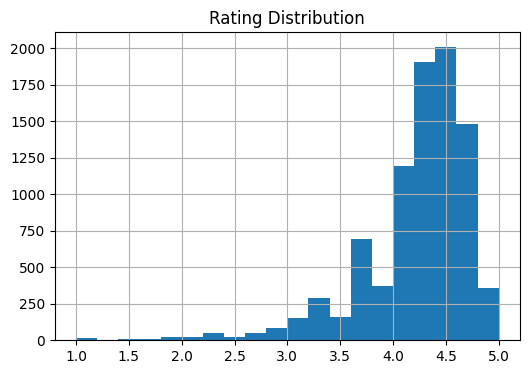

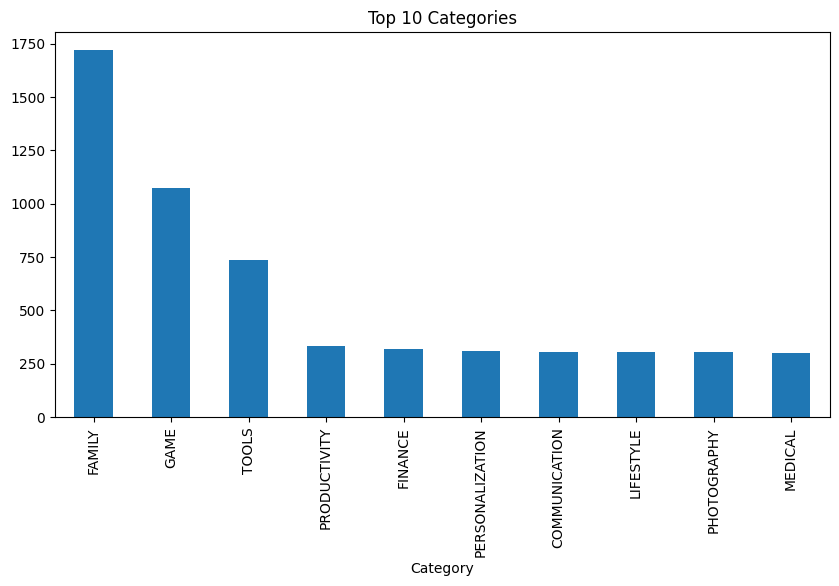

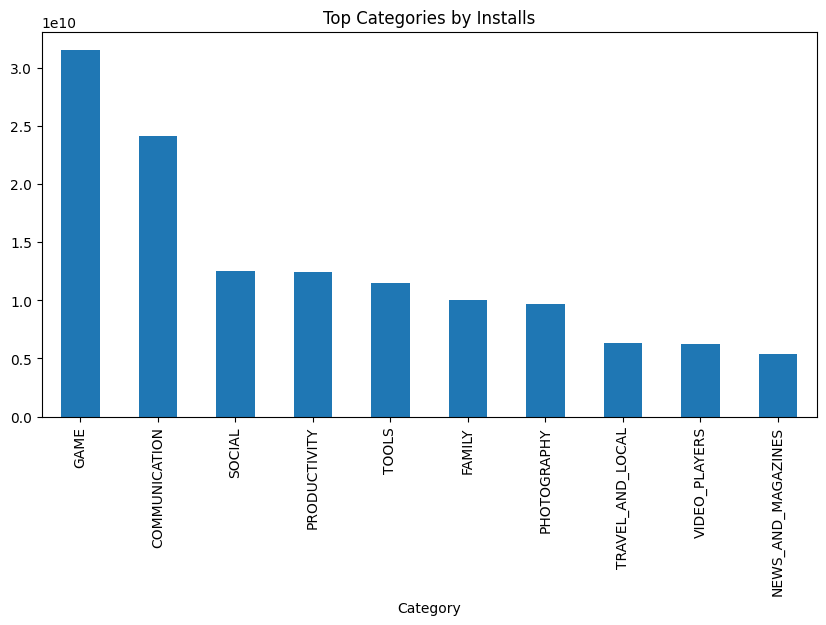

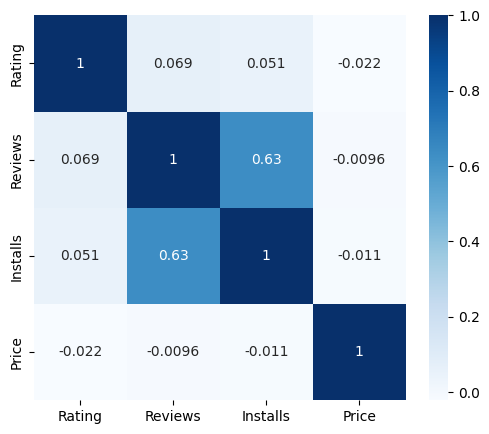

In [4]:
# Visualizations
plt.figure(figsize=(6,4))
df['Rating'].hist(bins=20)
plt.title('Rating Distribution')
plt.show()

plt.figure(figsize=(10,5))
df['Category'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Categories')
plt.show()

plt.figure(figsize=(10,5))
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top Categories by Installs')
plt.show()

if sns:
    plt.figure(figsize=(6,5))
    sns.heatmap(df[['Rating','Reviews','Installs','Price']].corr(numeric_only=True),annot=True,cmap='Blues')
    plt.show()


In [5]:
# Export Files
df.to_csv('clean_googleplaystore.csv',index=False)
df.to_excel('clean_googleplaystore.xlsx',index=False)
df.to_json('clean_googleplaystore.json',orient='records')

conn=sqlite3.connect('googleplaystore.db')
df.to_sql('apps',conn,if_exists='replace',index=False)

queries={
'SELECT':'SELECT App,Rating FROM apps LIMIT 10',
'WHERE':'SELECT App,Rating FROM apps WHERE Rating>=4.5 LIMIT 10',
'ORDER BY':'SELECT App,Reviews FROM apps ORDER BY Reviews DESC LIMIT 10',
'GROUP BY':'SELECT Category,COUNT(*) AS TotalApps FROM apps GROUP BY Category ORDER BY TotalApps DESC',
'COUNT':'SELECT COUNT(*) AS TotalApps FROM apps',
'AVG':'SELECT AVG(Rating) AS AvgRating FROM apps',
'MAX':'SELECT MAX(Rating) AS HighestRating FROM apps',
'MIN':'SELECT MIN(Rating) AS LowestRating FROM apps',
'DISTINCT':'SELECT DISTINCT Category FROM apps',
'HAVING':'SELECT Category,AVG(Rating) AS AvgRating FROM apps GROUP BY Category HAVING AvgRating>4.3',
'LIMIT':'SELECT App,Installs FROM apps ORDER BY Installs DESC LIMIT 5'
}

for name,q in queries.items():
    print("\n====",name,"====")
    print(pd.read_sql_query(q,conn))

conn.close()

print("Done! Files exported:")
print("clean_googleplaystore.csv")
print("clean_googleplaystore.xlsx")
print("clean_googleplaystore.json")
print("googleplaystore.db")



==== SELECT ====
                                                 App  Rating
0     Photo Editor & Candy Camera & Grid & ScrapBook     4.1
1                                Coloring book moana     3.9
2  U Launcher Lite – FREE Live Cool Themes, Hide ...     4.7
3                              Sketch - Draw & Paint     4.5
4              Pixel Draw - Number Art Coloring Book     4.3
5                         Paper flowers instructions     4.4
6            Smoke Effect Photo Maker - Smoke Editor     3.8
7                                   Infinite Painter     4.1
8                               Garden Coloring Book     4.4
9                      Kids Paint Free - Drawing Fun     4.7

==== WHERE ====
                                                 App  Rating
0  U Launcher Lite – FREE Live Cool Themes, Hide ...     4.7
1                              Sketch - Draw & Paint     4.5
2                      Kids Paint Free - Drawing Fun     4.7
3                              Mandala Coloring Bo